# Práctica 1: Obteniendo el potencial y el campo eléctrico a partir de una distribución de carga

Por la 1ª ley de Maxwell, se tiene que una distribución de carga $\rho$ genera un potencial eléctrico $\phi$

$$\nabla^2 \phi(\textbf{r})=-\frac{\rho(\textbf{r})}{\epsilon_0},$$

que, en coordenadas cartesianas en dos dimensiones, toma la forma

$$\left(\frac{\partial^2}{\partial x^2}+\frac{\partial^2}{\partial y^2}\right) \phi(x,y)=-\frac{\rho(x,y)}{\epsilon_0}.$$

Veremos cómo resolver esta ecuación en derivadas parciales (EDP) en el Tema 8. Sin embargo, puede obtenerse la solución de la ecuación a partir de la función de Green asociada, es decir, resolviendo la siguiente integral extendida a todo el espacio

$$\phi(\textbf{r})=\frac{1}{4 \pi \epsilon_0}\int\int \frac{\rho(\textbf{r'})}{|\textbf{r}-\textbf{r'}|}d^2\textbf{r'}.$$

1. **[2 pts]** Dada la siguiente distribución de carga bidimensional en polares,

    $$\rho(r,\varphi)=
  \left\{ 
    \begin{array}{cc}
      \rho_0e^{-\frac{1}{1-r^3}}\sin(8\varphi) &\hspace{5mm} 0\leq r <1 , \hspace{5mm} 0\leq \varphi \leq2\pi \\
      0 & \hspace{5mm} \text{en otro caso}
    \end{array} \right.
    \,,$$

    con $\rho_0=100 \, \text{C}\,\text{m}^{-3}$, representarla para $-1\leq x\leq 1$, $-1\leq y\leq 1$ (coordenadas cartesianas) en un grid $1000\times 1000$. 
    
    $\textbf{Ayuda:}$ 
    - Para ello, podría ser de ayuda utilizar el comando $\textbf{vectorize}$.
    - Para calcular de forma correcta $\arctan(y/x)$, se recomienda el uso de la función $\textbf{arctan2(y,x)}$ de $\textbf{numpy}$.
    - Se recomienda utilizar el patrón de color $\textbf{seismic}$ de $\textbf{imshow}$.

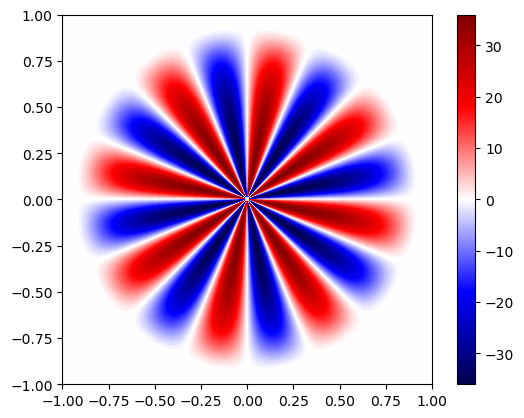

In [20]:
import numpy as np
import matplotlib.pyplot as plt

eps0 = 8.85*10**(-12)
k = 1/(4*np.pi*eps0)
p0 = 100

def p(r, phi):
    if r >= 1:
        return 0
    return p0*np.exp(-1/(1-r**3))*np.sin(8*phi)

p = np.vectorize(p)

t = np.linspace(-1,1,1000)
X, Y = np.meshgrid(t, t)

R = np.sqrt(X**2+Y**2)
PHI = np.arctan2(Y, X)

plt.imshow(p(R, PHI), cmap="seismic", extent=[-1,1,-1,1])
plt.colorbar()
plt.show()

2. **[3,5 pts]** Definir una función que proporcione el potencial eléctrico $\phi$ generado por la distribución de carga del apartado anterior (recuerda que $\epsilon_0=8.85\times 10^{-12}\,\text{C}^2\,\text{N}^{-1}\,\text{m}^{-2}$). Justificar el método de integración utilizado.

    $\textbf{Ayuda:}$ 
    - Integrar la distribución de carga en el dominio donde es distinta de $0$, no en todo el espacio.
    - Si se calcula la integral en polares, prestar atención al elemento diferencial de superficie.

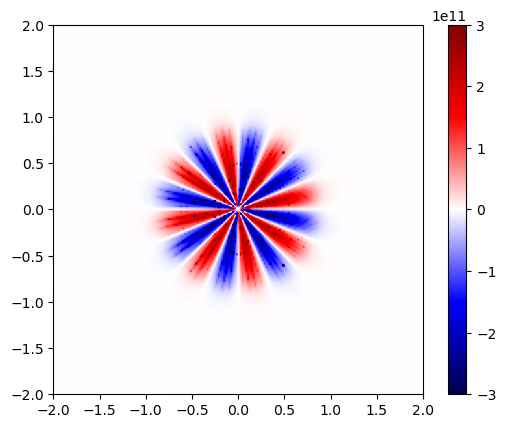

In [41]:
# Empleamos el método del trapecio SIN ADAPTAR porque:
    # 1. El adaptato puede tardar demasiado
    # 2. La cuadratura gaussiana muestrea mucho en los extremos y poco en el centro, que es donde nos interesa muestrear habida cuenta de la forma de la distribución de carga
    
# import numpy as np
# from gaussxw import gaussxwab

# r_roots, w_r = gaussxwab(100, 0,1)
# phi_roots, w_phi = gaussxwab(100, 0,2*np.pi)

# def V(r, phi):
#     f = lambda r_p, phi_p: p(r_p, phi_p) / np.sqrt( r**2+r_p**2-2*r*r_p*( np.cos(phi)*np.cos(phi_p) + np.sin(phi)*np.sin(phi_p) ) )
#     I = 0
#     for i in range(len(r_roots)):
#         for j in range(len(phi_roots)):
#             I+= w_r[i]*w_phi[j]*f(r_roots[i], phi_roots[j])
#     return k*I


# t = np.linspace(-2, 2, 200)
# X, Y = np.meshgrid(t, t)

# R = np.sqrt(X**2+Y**2)
# PHI = np.arctan2(Y, X)

# pot = V(R, PHI)

plt.imshow(pot, origin="lower", cmap="seismic", vmax=3*10**11, vmin=-3*10**11, extent=[-2,2,-2,2])
plt.colorbar()
plt.show()

En el interior de la distribución ($0\leq r < 1$):

$$\phi(r,\varphi)=\frac{\rho_0}{4\pi\varepsilon_0}\int_0^{2\pi}\int_0^r \frac{r'e^{-\frac{1}{1-r'^3}}\sin(8\varphi')}{\sqrt{r^2+r'^2-2rr'(\cos\varphi\cos\varphi'+\sin\varphi\sin\varphi')}}dr'd\varphi'$$

En el exterior de la distribución ($r\geq 1$):

$$\phi(r,\varphi)=\frac{\rho_0}{4\pi\varepsilon_0}\int_0^{2\pi}\int_0^1 \frac{r'e^{-\frac{1}{1-r'^3}}\sin(8\varphi')}{\sqrt{r^2+r'^2-2rr'(\cos\varphi\cos\varphi'+\sin\varphi\sin\varphi')}}dr'd\varphi'$$

3. **[1 pt]** Representar el potencial eléctrico para $-2\leq x\leq 2$, $-2\leq y\leq 2$ en un grid $200\times 200$ (se recomienda utilizar $v_{max}=10^{11}\,$V y $v_{min}=-10^{11}\,$V en $\textbf{imshow}$).

4. **[2,5 pts]** A partir del potencial eléctrico, puede calcularse el campo eléctrico, en un régimen electrostático, de la siguiente forma

    $$\textbf{E}=- \boldsymbol{\nabla} \phi,$$

    que en coordenadas cartesianas bidimensionales, toma la forma
    
    $$E_x=-\frac{\partial \phi}{\partial x} \hspace{3mm},\hspace{3mm}E_y=-\frac{\partial \phi}{\partial y}.$$
    
    Calcular el campo eléctrico en $-2\leq x\leq 2$, $-2\leq y\leq 2$ a partir de la función definida en el apartado 2 (es decir, el potencial eléctrico $\phi$) en un grid $60\times 60$.

5. **[1 pt]** Representar el campo eléctrico calculado en el apartado anterior mediante el comando $\textbf{quiver}$ del paquete $\textbf{matplotlib.pyplot}$ (una vez calculados $E_x$ y $E_y$, basta hacer uso de $\textbf{quiver}(E_x,E_y)$).

6. **[Extra: 1 pt]** Si has llegado al resultado correcto, observarás que el campo tiene una simetría parecida a la distribución de carga, pero en algunos puntos el módulo del campo eléctrico es muy elevado. Ello ocurre cuando se calcula $\phi$ en un punto muy cercano a uno de los puntos donde se evalúa el integrando, de forma que éste se vuelve muy grande y puede haber errores numéricos. Vuelve a representar $E_x$ y $E_y$, pero esta vez cuando $|E_{x,y}|>C$ (por ejemplo, $C=10^{11}\, \text{N}\,\text{C}^{-1}$), sustituye $|E_{x,y}|=C$, y obtendrás el mismo resultado que en el apartado anterior, pero evitando los errores numéricos.